# 17 — Proposal figure v2

Fixes from v1 (nb16):
- **Colormap**: `gray` (white stars, black sky) instead of `gray_r` (which inverts colours)
- **Background**: white figure background, dark image panels (paper-friendly)
- **Stretch**: default `sqrt` — gentler than arcsinh, shows more midtones; easily switched
- **Sim image**: auto-fallback to `110lmm50mm.fits` (which solved in nb15) if
  `100lmm50mm_sim.fits` still fails; optionally flip horizontally

Produces two figures:
1. **Two-panel**: real + sim side by side
2. **One-panel**: real image only (for fallback / standalone use)

**Run from the `Python (spectrangle WSL)` kernel.**


In [1]:
import sys, shutil, warnings, time, platform, pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from astropy.io import fits
from astropy.wcs import WCS, FITSFixedWarning
from astropy.wcs.utils import proj_plane_pixel_scales

_pkg_root = str(Path('..').resolve())
if _pkg_root not in sys.path:
    sys.path.insert(0, _pkg_root)

from extractor import extract_stars
from extractor.platesolve import solve_plate, LocalSolveFieldError
from extractor.wcsangle import center_wcs_angle_metrics

BACKEND_CFG = '/mnt/c/Users/bassd/.astrometry/backend.cfg'
INDEX_DIR   = Path('/mnt/c/Users/bassd/astrometry-data/4100/')

def _make_wcs(header):
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', category=FITSFixedWarning)
        warnings.filterwarnings('ignore', message='.*datfix.*')
        return WCS(header)

import extractor
print(f'extractor   : {extractor.__version__}')
print(f'Platform    : {platform.system()} {platform.release()}')
if platform.system() == 'Windows':
    print('\n*** WARNING: Windows kernel — switch to Python (spectrangle WSL) kernel')
sf = shutil.which('solve-field')
print(f'solve-field : {sf or "NOT FOUND"}')


extractor   : 0.2.0
Platform    : Linux 5.15.167.4-microsoft-standard-WSL2
solve-field : /usr/bin/solve-field


## Parameters

All adjustable values are here.  The most commonly tweaked ones are:

| Parameter | What it controls |
|:----------|:-----------------|
| `STRETCH` | `'sqrt'` (default, lighter), `'arcsinh'` (more contrast), `'linear'` |
| `VHI_PCT_*` | Upper percentile clip — raise to show fainter stars, lower to reduce saturation |
| `VLO_PCT_*` | Lower clip — raise to cut more sky background |
| `ARCSINH_SCALE_FRAC` | Only used for `'arcsinh'` stretch; larger → more linear / lighter |
| `FORCE_110_FALLBACK` | Set `True` to skip the 100lmm solve attempt and go straight to 110lmm |
| `FLIP_SIM_LR` | Flip the 110lmm fallback image left-right |


In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR       = Path('..') / 'data'
OUT_DIR        = Path('..') / 'out' / 'proposal_fig_v2'
OUT_DIR.mkdir(parents=True, exist_ok=True)

REAL_FILE      = DATA_DIR / 'fig' / 'fuji6_asi178_100_15s.fit'
SIM_100_FILE   = DATA_DIR / 'fig' / '100lmm50mm_sim.fits'   # attempt first
SIM_110_FILE   = DATA_DIR / '110lmm50mm.fits'                # fallback

# ── Sim image strategy ─────────────────────────────────────────────────────────
# Set FORCE_110_FALLBACK=True to skip the 100lmm solve and use 110lmm directly.
FORCE_110_FALLBACK = False
FLIP_SIM_LR        = True    # flip the 110lmm fallback image left-right for display

# ── Brightness stretch ─────────────────────────────────────────────────────────
# STRETCH options: 'sqrt' (lighter, recommended), 'arcsinh' (more log-like),
#                  'linear' (raw percentile clip, flattest)
STRETCH          = 'sqrt'

BG_SIGMA         = 50.0     # Gaussian background kernel (px) — same for both

# Percentile clip applied to the background-subtracted image before stretch.
#   Raise VHI to reveal fainter structures.  Lower VLO to cut more sky.
VLO_PCT_REAL     = 0.5
VHI_PCT_REAL     = 99.8
VLO_PCT_SIM      = 0.5
VHI_PCT_SIM      = 99.8

# For STRETCH='arcsinh' only: divisor = hi * ARCSINH_SCALE_FRAC.
#   Larger value → more linear (lighter).  Default 0.3 → moderate.
ARCSINH_SCALE_FRAC = 0.3

# ── Figure style ───────────────────────────────────────────────────────────────
# CMAP='gray': white stars, black sky.  Standard astronomical convention.
# Do NOT change to 'gray_r' — it inverts star/sky brightness.
CMAP             = 'gray'

# Colourmap for the source/compass overlays (always drawn on a dark image panel,
# so these stay constant regardless of figure background colour).
DET_COLOR        = '#44ff88'    # detected sources (lime)
MATCH_COLOR      = '#ff9900'    # catalog-matched sources (orange)
COMPASS_COLOR    = '#ffe066'    # north/east arrows (yellow)
GT_COLOR         = '#ff6b6b'    # GT grating angle placeholder (red)
GRID_COLOR       = '#4477aa'    # WCS grid (mid-blue, visible on dark image)

FIG_W_2PAN       = 16.0         # two-panel figure width  (inches)
FIG_H_2PAN       = 6.5          # two-panel figure height (inches)
FIG_W_1PAN       = 9.0          # one-panel figure width  (inches)
FIG_H_1PAN       = 6.5          # one-panel figure height (inches)
FIG_DPI          = 150

ARROW_LEN_FRAC   = 0.07         # north arrow length as fraction of min(nx, ny)
ARROW_POS_X      = 0.10         # arrow base x (fraction of image width)
ARROW_POS_Y      = 0.12         # arrow base y (fraction of image height)
COMPASS_FS       = 12

DET_SZ           = 14           # detected marker area (pt²)
MATCH_SZ         = 70           # matched marker area (pt²)
MATCH_LW         = 1.3

TITLE_FS         = 11
LABEL_FS         = 10
ANN_FS           = 8.5
LEGEND_FS        = 8
SUPTITLE_FS      = 12

# ── Solve parameters ───────────────────────────────────────────────────────────
REAL_SCALE_LOW   = 70.0
REAL_SCALE_HIGH  = 95.0
REAL_TWEAK_ORDER = 5

SIM_SCALE_LOW    = 8.0
SIM_SCALE_HIGH   = 13.0         # slightly wider than v1 to improve odds
SIM_TWEAK_ORDER  = 4
SIM_TIMEOUT      = 240          # longer timeout for harder image

# ── Shared caches ──────────────────────────────────────────────────────────────
NB10_FID  = Path('..') / 'out' / 'local_bootstrap_10' / 'fiducial_result.pkl'
NB10_SRC  = Path('..') / 'out' / 'local_bootstrap_10' / 'sources.pkl'
NB15_FID  = Path('..') / 'out' / 'local_bootstrap_15' / 'fiducial_result.pkl'

REAL_SRC_CACHE  = OUT_DIR / 'real_sources.pkl'
SIM_SRC_CACHE   = OUT_DIR / 'sim_sources.pkl'
SIM_SOLVE_CACHE = OUT_DIR / 'sim_fiducial.pkl'  # only for 100lmm attempt

print('File check:')
for p, lbl in [
    (REAL_FILE,    'real   '),
    (SIM_100_FILE, 'sim100 '),
    (SIM_110_FILE, 'sim110 '),
]:
    print(f'  {lbl}: {p.name}  exists={p.exists()}')
print(f'nb10 cache: fid={NB10_FID.exists()} src={NB10_SRC.exists()}')
print(f'nb15 cache: fid={NB15_FID.exists()}')


File check:
  real   : fuji6_asi178_100_15s.fit  exists=True
  sim100 : 100lmm50mm_sim.fits  exists=True
  sim110 : 110lmm50mm.fits  exists=True
nb10 cache: fid=True src=True
nb15 cache: fid=True


## Load images and compute display stretch


Real  : 3096×2080  vmin=0.000 vmax=0.244
Sim100: 3096×2080  vmin=0.000 vmax=19.195
Sim110: 3096×2080  vmin=0.000 vmax=33.031
  flip_lr=True

MASKANG header values:
  sim100: MASKANG=337.0  RA0DEG=40.0  DEC0DEG=65.0  PSARC=9.900710699860625
  sim110: MASKANG=23.0  RA0DEG=10.12724197930297  DEC0DEG=56.53718879378639  PSARC=9.900710699860625


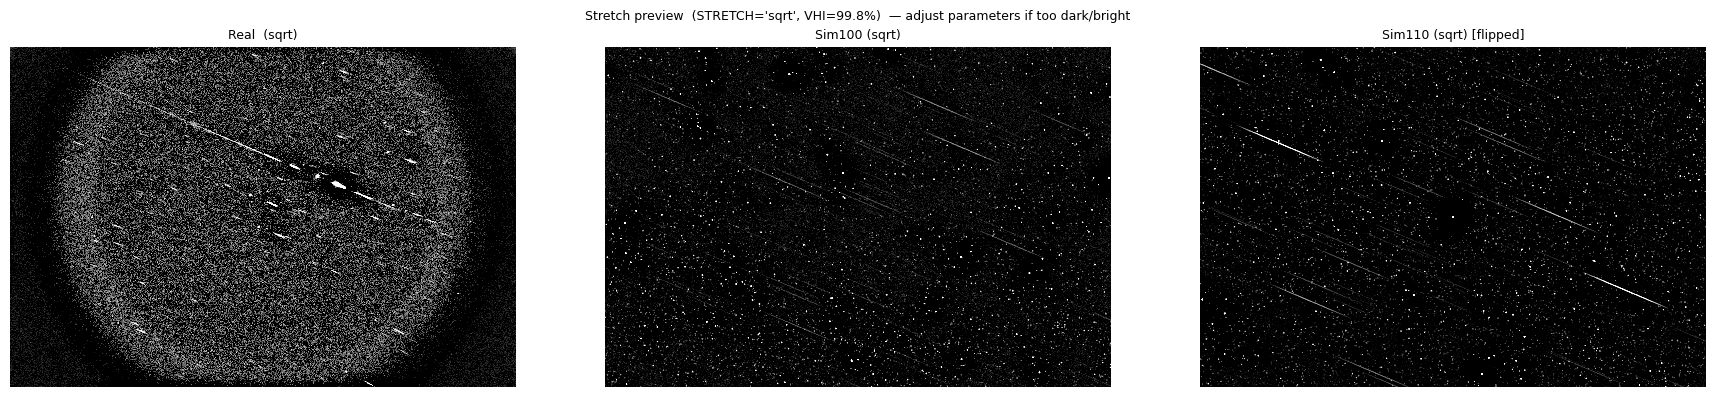

In [3]:
def stretch_image(image, vlo_pct, vhi_pct, bg_sigma, stretch, arcsinh_scale_frac):
    """
    Background-subtract and stretch an image for display.

    Returns (disp, vmin, vmax) ready for imshow(..., cmap='gray', vmin=vmin, vmax=vmax).

    stretch options
    ---------------
    'sqrt'    : square-root — lighter than arcsinh, shows more midtones (default)
    'arcsinh' : asinh — stronger log-like compression; adjust arcsinh_scale_frac
    'linear'  : simple percentile clip, no further compression (flattest)

    arcsinh_scale_frac (only for 'arcsinh')
    ----------------------------------------
    divisor = hi * arcsinh_scale_frac; larger = more linear / lighter.
    0.1 = aggressive,  0.3 = moderate,  1.0 = nearly linear.
    """
    bg   = gaussian_filter(image, sigma=bg_sigma)
    proc = np.clip(image - bg, 0.0, None).astype(np.float32)
    lo, hi = np.percentile(proc[np.isfinite(proc)], [vlo_pct, vhi_pct])
    clipped = np.clip(proc, lo, hi) - lo          # shift to [0, hi-lo]
    hi_shift = hi - lo

    if stretch == 'sqrt':
        disp = np.sqrt(clipped)
        vmin, vmax = 0.0, float(np.sqrt(hi_shift))
    elif stretch == 'arcsinh':
        scale = hi_shift * arcsinh_scale_frac if hi_shift > 0 else 1.0
        disp  = np.arcsinh(clipped / scale)
        vmin, vmax = 0.0, float(np.arcsinh(hi_shift / scale))
    else:  # linear
        disp = clipped
        vmin, vmax = 0.0, float(hi_shift)

    return disp, vmin, vmax


def load_image(path):
    with fits.open(path) as h:
        data   = h[0].data.astype(np.float32)
        header = h[0].header.copy()
    return data, header


image_real, hdr_real = load_image(REAL_FILE)
ny_real, nx_real = image_real.shape
disp_real, vmin_real, vmax_real = stretch_image(
    image_real, VLO_PCT_REAL, VHI_PCT_REAL, BG_SIGMA, STRETCH, ARCSINH_SCALE_FRAC)

image_sim100, hdr_sim100 = load_image(SIM_100_FILE)
ny_sim100, nx_sim100 = image_sim100.shape
disp_sim100, vmin_sim100, vmax_sim100 = stretch_image(
    image_sim100, VLO_PCT_SIM, VHI_PCT_SIM, BG_SIGMA, STRETCH, ARCSINH_SCALE_FRAC)

image_sim110, hdr_sim110 = load_image(SIM_110_FILE)
ny_sim110, nx_sim110 = image_sim110.shape
disp_sim110, vmin_sim110, vmax_sim110 = stretch_image(
    image_sim110, VLO_PCT_SIM, VHI_PCT_SIM, BG_SIGMA, STRETCH, ARCSINH_SCALE_FRAC)

if FLIP_SIM_LR:
    # Display copy only — solve is done on original
    disp_sim110_disp = disp_sim110[:, ::-1]
else:
    disp_sim110_disp = disp_sim110

print(f'Real  : {nx_real}×{ny_real}  vmin={vmin_real:.3f} vmax={vmax_real:.3f}')
print(f'Sim100: {nx_sim100}×{ny_sim100}  vmin={vmin_sim100:.3f} vmax={vmax_sim100:.3f}')
print(f'Sim110: {nx_sim110}×{ny_sim110}  vmin={vmin_sim110:.3f} vmax={vmax_sim110:.3f}')
print(f'  flip_lr={FLIP_SIM_LR}')
print()
print('MASKANG header values:')
for lbl, hdr in [('sim100', hdr_sim100), ('sim110', hdr_sim110)]:
    print(f'  {lbl}: MASKANG={hdr.get("MASKANG","MISSING")}  '
          f'RA0DEG={hdr.get("RA0DEG","?")}  DEC0DEG={hdr.get("DEC0DEG","?")}'
          f'  PSARC={hdr.get("PSARC","?")}') 

# Quick stretch preview — check before running solves
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, disp, vmin, vmax, title in [
    (axes[0], disp_real,       vmin_real,   vmax_real,   f'Real  ({STRETCH})'),
    (axes[1], disp_sim100,     vmin_sim100, vmax_sim100, f'Sim100 ({STRETCH})'),
    (axes[2], disp_sim110_disp,vmin_sim110, vmax_sim110, f'Sim110 ({STRETCH}){" [flipped]" if FLIP_SIM_LR else ""}'),
]:
    ax.imshow(disp, origin='lower', cmap=CMAP, vmin=vmin, vmax=vmax,
              aspect='equal', interpolation='nearest')
    ax.set_title(title, fontsize=9)
    ax.axis('off')
fig.suptitle(
    f'Stretch preview  (STRETCH={STRETCH!r}, VHI={VHI_PCT_REAL}%)  '
    f'— adjust parameters if too dark/bright',
    fontsize=9)
fig.tight_layout()
plt.show()


## Source detection (cached)


In [4]:
def get_sources(image, path, cache, alt_cache=None):
    for p, lbl in [(alt_cache, 'alt'), (cache, 'local')]:
        if p is not None and Path(p).exists():
            with open(p, 'rb') as f:
                xs, ys, fl = pickle.load(f)
            print(f'  {path.name}: {len(xs)} sources ({lbl} cache)')
            return xs, ys, fl
    print(f'  {path.name}: detecting...')
    xs, ys, fl = extract_stars(image, max_sources=300, mask_spectra=True)
    with open(cache, 'wb') as f:
        pickle.dump((xs, ys, fl), f)
    print(f'  {path.name}: {len(xs)} sources (cached)')
    return xs, ys, fl

xs_real, ys_real, _ = get_sources(image_real,   REAL_FILE,    REAL_SRC_CACHE, NB10_SRC)
xs_sim,  ys_sim,  _ = get_sources(image_sim100,  SIM_100_FILE, SIM_SRC_CACHE)
xs_110,  ys_110,  _ = get_sources(image_sim110,  SIM_110_FILE,
                                   OUT_DIR / 'sim110_sources.pkl',
                                   Path('..') / 'out' / 'local_bootstrap_15' / 'sources.pkl')


  fuji6_asi178_100_15s.fit: 255 sources (alt cache)
  100lmm50mm_sim.fits: detecting...
  100lmm50mm_sim.fits: 287 sources (cached)
  110lmm50mm.fits: 287 sources (alt cache)


## Solve / load: real image


In [5]:
REAL_SOLVE_CACHE = OUT_DIR / 'real_fiducial.pkl'

for p, lbl in [(NB10_FID, 'nb10'), (REAL_SOLVE_CACHE, 'local')]:
    if p.exists():
        print(f'Loading real solve from {lbl} cache')
        with open(p, 'rb') as f:
            result_real = pickle.load(f)
        break
else:
    print(f'Running real-image solve ({len(xs_real)} sources)...')
    _idx = str(INDEX_DIR / 'index-4117.fits')
    _extra = ['--index', _idx] if Path(_idx).exists() else None
    _t0 = time.time()
    try:
        result_real = solve_plate(
            xs=xs_real, ys=ys_real,
            image_width=nx_real, image_height=ny_real,
            original_header=hdr_real,
            backend='local', backend_config=BACKEND_CFG,
            scale_units='arcsecperpix',
            scale_low=REAL_SCALE_LOW, scale_high=REAL_SCALE_HIGH,
            tweak_order=REAL_TWEAK_ORDER,
            output_dir=OUT_DIR / 'real_solve',
            timeout=120, verbose=True, extra_args=_extra,
        )
    except LocalSolveFieldError as e:
        print(f'Solve error: {e}')
        result_real = None
    print(f'Finished in {time.time()-_t0:.1f}s')
    if result_real is not None:
        with open(REAL_SOLVE_CACHE, 'wb') as f:
            pickle.dump(result_real, f)

if result_real is not None:
    wcs_real     = _make_wcs(result_real.header)
    metrics_real = center_wcs_angle_metrics(wcs_real, image_real.shape, compute_east=True)
    _ps = float(np.mean(np.abs(proj_plane_pixel_scales(wcs_real))) * 3600)
    n_match_real = (len(result_real.corr_table)
                    if result_real.corr_table is not None
                    else len(result_real.matched_x))
    print(f'OK: matched={n_match_real}  scale={_ps:.1f}"/px  '
          f'θ_N={metrics_real.north_angle_deg:.3f}°')
else:
    wcs_real = metrics_real = None
    print('WARNING: real image solve failed')


Loading real solve from nb10 cache
OK: matched=86  scale=80.4"/px  θ_N=-107.006°


## Solve / load: sim image  (with 110lmm fallback)

Strategy:
1. If `FORCE_110_FALLBACK=True` → load nb15 result immediately (110lmm, flipped)
2. Otherwise, try to solve `100lmm50mm_sim.fits` with a broader search
3. If that fails → fall back to 110lmm + horizontal flip


In [6]:
def flip_wcs_lr(header, nx):
    """Return a modified header whose WCS matches a left-right flipped image.
    Only valid for pure TAN (no SIP) WCS — which is the case for 110lmm solve.
    For a horizontal flip (x → nx-1-x, 0-indexed):
      CRPIX1_new = nx + 1 - CRPIX1_old  (FITS 1-indexed)
      CD1_1, CD2_1 both negate (RA-x and Dec-x columns)
    """
    h = header.copy()
    h['CRPIX1'] = float(nx + 1) - float(h['CRPIX1'])
    for key in ('CD1_1', 'CD2_1'):
        if key in h:
            h[key] = -h[key]
    for key in ('PC1_1', 'PC2_1'):  # PC matrix variant
        if key in h:
            h[key] = -h[key]
    # CDELT form (no CD): negate CDELT1 instead
    if 'CD1_1' not in h and 'PC1_1' not in h and 'CDELT1' in h:
        h['CDELT1'] = -h['CDELT1']
    return h


def load_110lmm_result():
    """Load nb15 fiducial result for 110lmm50mm.fits; optionally flip WCS/coords."""
    with open(NB15_FID, 'rb') as f:
        r = pickle.load(f)
    if FLIP_SIM_LR:
        r.header = flip_wcs_lr(r.header, nx_sim110)
        # Flip x-coordinates of detected and matched sources
        r.detected_x = (nx_sim110 - 1) - r.detected_x
        r.matched_x  = (nx_sim110 - 1) - r.matched_x
        if r.corr_table is not None and 'field_x' in r.corr_table.colnames:
            from astropy.table import Table
            t = r.corr_table.copy()
            t['field_x'] = (nx_sim110 - 1) - np.asarray(t['field_x'], dtype=float)
            r.corr_table = t
    return r


# --- Resolve which sim result to use ---
sim_image   = None
sim_disp    = None
sim_vmin    = None
sim_vmax    = None
sim_nx      = None
sim_ny      = None
result_sim  = None
wcs_sim     = None
metrics_sim = None
sim_label   = ''
sim_maskang = None   # GT grating angle (pixel-space, CCW from +x)

used_fallback = False

if not FORCE_110_FALLBACK:
    # Try 100lmm with broader parameters (no specific index restriction)
    if SIM_SOLVE_CACHE.exists():
        print('Loading 100lmm solve from cache...')
        with open(SIM_SOLVE_CACHE, 'rb') as f:
            result_sim = pickle.load(f)
    else:
        _ra  = float(hdr_sim100.get('RA0DEG',  0))
        _dec = float(hdr_sim100.get('DEC0DEG', 0))
        print(f'Attempting 100lmm solve (scale {SIM_SCALE_LOW}–{SIM_SCALE_HIGH}"')
        print(f'  hint: RA={_ra:.2f}°, Dec={_dec:.2f}°, timeout={SIM_TIMEOUT}s)...')
        _t0 = time.time()
        try:
            result_sim = solve_plate(
                xs=xs_sim, ys=ys_sim,
                image_width=nx_sim100, image_height=ny_sim100,
                original_header=hdr_sim100,
                backend='local', backend_config=BACKEND_CFG,
                scale_units='arcsecperpix',
                scale_low=SIM_SCALE_LOW, scale_high=SIM_SCALE_HIGH,
                tweak_order=SIM_TWEAK_ORDER,
                output_dir=OUT_DIR / 'sim100_solve',
                timeout=SIM_TIMEOUT, verbose=True,
                extra_args=['--ra', str(_ra), '--dec', str(_dec), '--radius', '15'],
            )
        except LocalSolveFieldError as e:
            print(f'Solve error: {e}')
            result_sim = None
        print(f'Finished in {time.time()-_t0:.1f}s')
        if result_sim is not None:
            with open(SIM_SOLVE_CACHE, 'wb') as f:
                pickle.dump(result_sim, f)

if result_sim is not None and not FORCE_110_FALLBACK:
    sim_image  = image_sim100
    sim_disp   = disp_sim100
    sim_vmin   = vmin_sim100
    sim_vmax   = vmax_sim100
    sim_nx, sim_ny = nx_sim100, ny_sim100
    sim_label  = SIM_100_FILE.name
    sim_maskang = float(hdr_sim100.get('MASKANG', np.nan))
    print('Using 100lmm sim.')
else:
    # ── Fall back to 110lmm50mm.fits (nb15 cached solve) ──────────────────────
    used_fallback = True
    if not NB15_FID.exists():
        raise FileNotFoundError(
            f'nb15 fiducial cache not found: {NB15_FID}\n'
            'Re-run notebook 15 to generate it.')
    print(f'Falling back to 110lmm50mm.fits (nb15 cache){" + LR flip" if FLIP_SIM_LR else ""}')
    result_sim  = load_110lmm_result()
    sim_image   = image_sim110
    sim_disp    = disp_sim110_disp
    sim_vmin    = vmin_sim110
    sim_vmax    = vmax_sim110
    sim_nx, sim_ny = nx_sim110, ny_sim110
    sim_label   = SIM_110_FILE.name + (' [flipped]' if FLIP_SIM_LR else '')
    _raw_maskang = float(hdr_sim110.get('MASKANG', np.nan))
    # If flipped, reflect the angle: theta_flipped = 180 - theta_original
    sim_maskang = (180.0 - _raw_maskang) if (FLIP_SIM_LR and not np.isnan(_raw_maskang)) \
                  else _raw_maskang

wcs_sim     = _make_wcs(result_sim.header)
metrics_sim = center_wcs_angle_metrics(wcs_sim, (sim_ny, sim_nx), compute_east=True)
_ps_sim = float(np.mean(np.abs(proj_plane_pixel_scales(wcs_sim))) * 3600)
n_match_sim = (len(result_sim.corr_table)
               if result_sim.corr_table is not None
               else len(result_sim.matched_x))
print(f'Sim solve OK (used_fallback={used_fallback}):')
print(f'  image   : {sim_label}')
print(f'  matched : {n_match_sim}')
print(f'  scale   : {_ps_sim:.2f}"/px')
print(f'  θ_N     : {metrics_sim.north_angle_deg:.3f}°')
print(f'  MASKANG : {sim_maskang:.1f}° (GT grating angle, pixel-space CCW from +x)')


Attempting 100lmm solve (scale 8.0–13.0"
  hint: RA=40.00°, Dec=65.00°, timeout=240s)...
Wrote 287 sources → ../out/proposal_fig_v2/sim100_solve/xylist.fits
Running: /usr/bin/solve-field ../out/proposal_fig_v2/sim100_solve/xylist.fits --width 3096 --height 2080 --scale-units arcsecperpix --scale-low 8.0 --scale-high 13.0 --tweak-order 4 --dir ../out/proposal_fig_v2/sim100_solve --backend-config /mnt/c/Users/bassd/.astrometry/backend.cfg --overwrite --no-plots --ra 40.0 --dec 65.0 --radius 15
  Field 1 did not solve (index index-4112.fits, field objects 171-180).
  Field 1 did not solve (index index-4111.fits, field objects 171-180).
  Field 1 did not solve (index index-4110.fits, field objects 171-180).
  Field 1 did not solve (index index-4109.fits, field objects 171-180).
  Field 1 did not solve (index index-4107.fits, field objects 171-180).
  Field 1 did not solve (index index-4116.fits, field objects 181-190).
  Field 1 did not solve (index index-4115.fits, field objects 181-190).

## Helper functions


In [7]:
def draw_compass(ax, x_px, y_px, length_px, north_angle_deg,
                 east_angle_deg=None, color='yellow', fontsize=12):
    """N (and optionally E) compass arrows at pixel position (x_px, y_px)."""
    pix = ax.get_transform('pixel')
    th_n = np.radians(north_angle_deg)
    dx_n, dy_n = length_px * np.cos(th_n), length_px * np.sin(th_n)

    ax.annotate('',
        xy=(x_px + dx_n, y_px + dy_n), xytext=(x_px, y_px),
        xycoords=pix, textcoords=pix,
        arrowprops=dict(arrowstyle='->', color=color, lw=2.2, mutation_scale=16))
    ax.text(x_px + 1.30*dx_n, y_px + 1.30*dy_n, 'N',
            transform=pix, color=color, fontsize=fontsize,
            fontweight='bold', ha='center', va='center')

    if east_angle_deg is not None:
        th_e = np.radians(east_angle_deg)
        L_e  = length_px * 0.65
        dx_e, dy_e = L_e * np.cos(th_e), L_e * np.sin(th_e)
        ax.annotate('',
            xy=(x_px + dx_e, y_px + dy_e), xytext=(x_px, y_px),
            xycoords=pix, textcoords=pix,
            arrowprops=dict(arrowstyle='->', color=color, lw=1.6, mutation_scale=12))
        ax.text(x_px + 1.38*dx_e, y_px + 1.38*dy_e, 'E',
                transform=pix, color=color,
                fontsize=fontsize * 0.80, fontweight='bold',
                ha='center', va='center')


def draw_angle_line(ax, x_px, y_px, length_px, angle_deg,
                    color='red', linestyle='--', lw=2.0, label=None,
                    label_fontsize=10):
    """Double-headed line at angle_deg (CCW from +x) through (x_px, y_px)."""
    pix  = ax.get_transform('pixel')
    th   = np.radians(angle_deg)
    half = length_px / 2.0
    ax.plot([x_px - half*np.cos(th), x_px + half*np.cos(th)],
            [y_px - half*np.sin(th), y_px + half*np.sin(th)],
            color=color, linestyle=linestyle, linewidth=lw,
            transform=pix, solid_capstyle='round')
    if label is not None:
        ax.text(x_px + half*np.cos(th) + 8, y_px + half*np.sin(th) + 8,
                label, transform=pix, color=color,
                fontsize=label_fontsize, fontstyle='italic')


def make_panel(ax, disp, vmin, vmax, nx, ny,
               result, wcs_obj, metrics,
               title, file_label,
               maskang=None, show_gt=True,
               fg='black'):
    """
    Draw a complete proposal figure panel.

    Parameters
    ----------
    fg : str — colour for axis labels / ticks (black on white figure)
    """
    ax.set_facecolor('black')

    # ── Image ─────────────────────────────────────────────────────────────────
    ax.imshow(disp, origin='lower', cmap=CMAP,
              vmin=vmin, vmax=vmax,
              aspect='equal', interpolation='nearest')

    # ── WCS coordinate grid ───────────────────────────────────────────────────
    if wcs_obj is not None:
        ax.coords.grid(True, color=GRID_COLOR, alpha=0.35,
                       linestyle='--', linewidth=0.7)
        ax.coords['ra'].set_major_formatter('hh:mm')
        ax.coords['dec'].set_major_formatter('dd:mm')
        ax.coords['ra'].set_axislabel('Right Ascension',
                                       fontsize=LABEL_FS, color=fg)
        ax.coords['dec'].set_axislabel('Declination',
                                        fontsize=LABEL_FS, color=fg)
        ax.coords['ra'].set_ticklabel(color=fg, size=LABEL_FS - 1)
        ax.coords['dec'].set_ticklabel(color=fg, size=LABEL_FS - 1)
        ax.coords['ra'].set_ticks(color=fg)
        ax.coords['dec'].set_ticks(color=fg)
    else:
        ax.set_xlabel('x (px)', fontsize=LABEL_FS, color=fg)
        ax.set_ylabel('y (px)', fontsize=LABEL_FS, color=fg)
        ax.tick_params(colors=fg)

    # ── Source overlays ───────────────────────────────────────────────────────
    if result is not None:
        pix = ax.get_transform('pixel') if wcs_obj is not None else ax.transData
        ax.scatter(result.detected_x, result.detected_y,
                   transform=pix,
                   s=DET_SZ, facecolors='none', edgecolors=DET_COLOR,
                   linewidths=0.7, alpha=0.45, zorder=3,
                   label=f'detected ({len(result.detected_x)})')
        if result.corr_table is not None and 'field_x' in result.corr_table.colnames:
            mx = np.asarray(result.corr_table['field_x'], dtype=float)
            my = np.asarray(result.corr_table['field_y'], dtype=float)
            ax.scatter(mx, my, transform=pix,
                       s=MATCH_SZ, facecolors='none', edgecolors=MATCH_COLOR,
                       linewidths=MATCH_LW, alpha=0.85, zorder=4,
                       label=f'matched ({len(mx)})')
        elif hasattr(result, 'matched_x') and len(result.matched_x):
            ax.scatter(result.matched_x, result.matched_y, transform=pix,
                       s=MATCH_SZ, facecolors='none', edgecolors=MATCH_COLOR,
                       linewidths=MATCH_LW, alpha=0.85, zorder=4,
                       label=f'matched ({len(result.matched_x)})')

    # ── Compass fiducial ──────────────────────────────────────────────────────
    if metrics is not None:
        arrowlen = min(nx, ny) * ARROW_LEN_FRAC
        draw_compass(ax, nx * ARROW_POS_X, ny * ARROW_POS_Y, arrowlen,
                     metrics.north_angle_deg, metrics.east_angle_deg,
                     color=COMPASS_COLOR, fontsize=COMPASS_FS)

    # ── GT grating angle placeholder ──────────────────────────────────────────
    if show_gt and maskang is not None and not np.isnan(maskang) and metrics is not None:
        draw_angle_line(ax, nx / 2.0, ny / 2.0, min(nx, ny) * 0.28,
                        maskang, color=GT_COLOR, linestyle='--', lw=1.8,
                        label='GT grating angle')

    # ── Legend ────────────────────────────────────────────────────────────────
    ax.legend(fontsize=LEGEND_FS, loc='upper right',
              facecolor='#1a1a1a', edgecolor='#555555',
              labelcolor='white')

    # ── Annotation box (inside the dark image) ────────────────────────────────
    ann_lines = [file_label]
    if metrics is not None:
        _ps = float(np.mean(np.abs(proj_plane_pixel_scales(wcs_obj))) * 3600)
        ann_lines += [
            f'θ_N = {metrics.north_angle_deg:.2f}°',
            f'RA {metrics.ra_deg:.3f}°,  Dec {metrics.dec_deg:.3f}°',
            f'scale ≈ {_ps:.1f} "/px',
        ]
        if maskang is not None and not np.isnan(maskang):
            ann_lines.append(f'GT MASKANG = {maskang:.1f}°  (placeholder)')
    else:
        ann_lines.append('(solve failed — no WCS)')

    ax.text(0.02, 0.98, '\n'.join(ann_lines),
            transform=ax.transAxes, fontsize=ANN_FS,
            color='white', va='top', ha='left',
            bbox=dict(facecolor='#111111', alpha=0.75, edgecolor='#555555',
                      boxstyle='round,pad=0.35'))

    ax.set_title(title, fontsize=TITLE_FS, color=fg, pad=6)


print('Helper functions defined.')


Helper functions defined.


## Figure A — two-panel (real + sim)


/mnt/c/Users/bassd/Research/Spectra Angle/spectrangle/.venv/lib/python3.11/site-packages/astropy/wcs/wcsapi/fitswcs.py:367: UserWarning: 'WCS.all_world2pix' failed to converge to the requested accuracy.
After 20 iterations, the solution is diverging at least for one input point.
  warnings.warn(str(e))
/mnt/c/Users/bassd/Research/Spectra Angle/spectrangle/.venv/lib/python3.11/site-packages/astropy/wcs/wcsapi/fitswcs.py:367: UserWarning: 'WCS.all_world2pix' failed to converge to the requested accuracy.
After 20 iterations, the solution is diverging at least for one input point.
  warnings.warn(str(e))
/mnt/c/Users/bassd/Research/Spectra Angle/spectrangle/.venv/lib/python3.11/site-packages/astropy/wcs/wcsapi/fitswcs.py:367: UserWarning: 'WCS.all_world2pix' failed to converge to the requested accuracy.
After 20 iterations, the solution is diverging at least for one input point.
  warnings.warn(str(e))
/mnt/c/Users/bassd/Research/Spectra Angle/spectrangle/.venv/lib/python3.11/site-packages

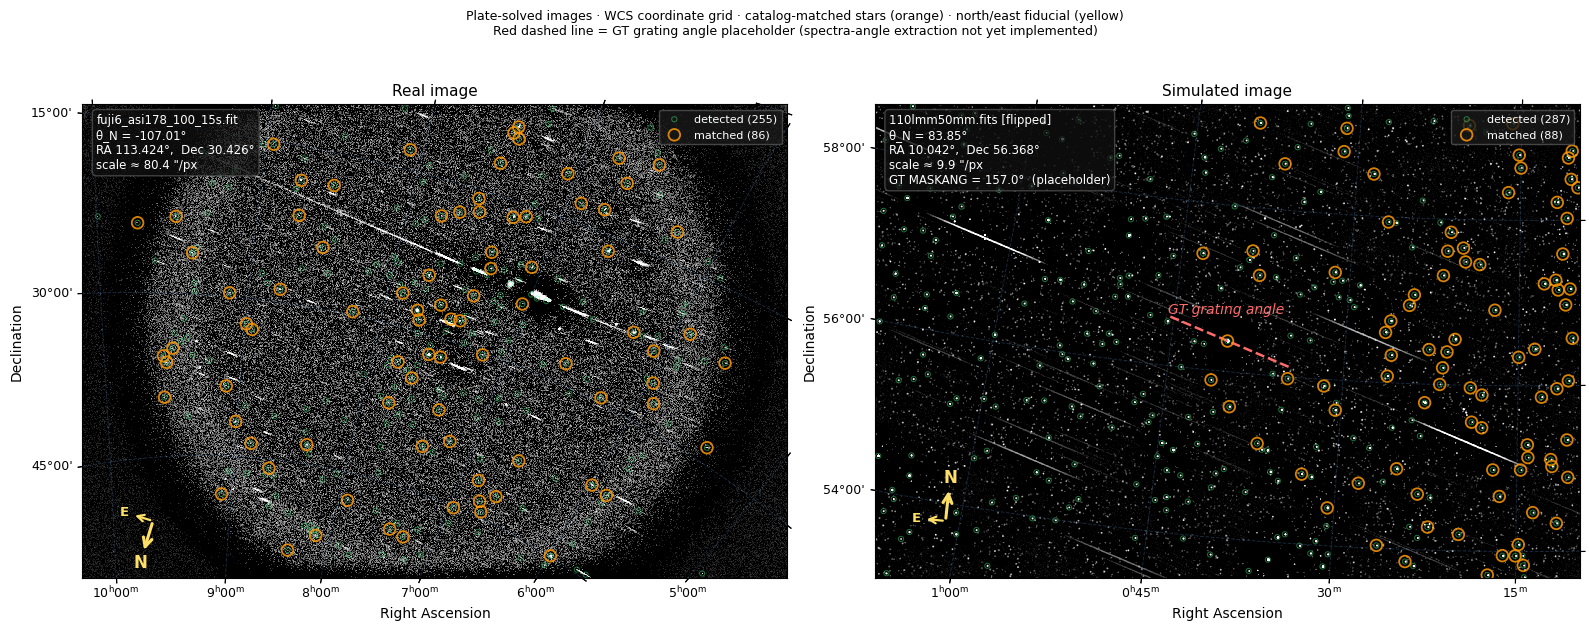

Saved: /mnt/c/Users/bassd/Research/Spectra Angle/spectrangle/out/proposal_fig_v2/proposal_2panel.png


In [8]:
plt.rcParams.update({
    'font.family':        'sans-serif',
    'text.color':         'black',
    'axes.labelcolor':    'black',
    'xtick.color':        'black',
    'ytick.color':        'black',
    'axes.edgecolor':     'black',
    'figure.facecolor':   'white',
    'axes.facecolor':     'black',
    'legend.facecolor':   '#1a1a1a',
    'legend.edgecolor':   '#555555',
    'savefig.facecolor':  'white',
    'savefig.dpi':         FIG_DPI,
})

fig2 = plt.figure(figsize=(FIG_W_2PAN, FIG_H_2PAN))
fig2.patch.set_facecolor('white')

ax_real = fig2.add_subplot(1, 2, 1, projection=wcs_real)  if wcs_real is not None else fig2.add_subplot(1, 2, 1)
ax_sim  = fig2.add_subplot(1, 2, 2, projection=wcs_sim)   if wcs_sim  is not None else fig2.add_subplot(1, 2, 2)

make_panel(ax_real,
           disp_real, vmin_real, vmax_real, nx_real, ny_real,
           result_real, wcs_real, metrics_real,
           title='Real image', file_label=REAL_FILE.name,
           maskang=None, show_gt=False)

make_panel(ax_sim,
           sim_disp, sim_vmin, sim_vmax, sim_nx, sim_ny,
           result_sim, wcs_sim, metrics_sim,
           title='Simulated image', file_label=sim_label,
           maskang=sim_maskang, show_gt=True)

_subtitle = (
    'Plate-solved images · WCS coordinate grid · catalog-matched stars (orange) · '
    'north/east fiducial (yellow)\n'
    'Red dashed line = GT grating angle placeholder '
    '(spectra-angle extraction not yet implemented)'
)
fig2.suptitle(_subtitle, fontsize=9, color='black', y=1.01)

fig2.tight_layout()
_out2 = OUT_DIR / 'proposal_2panel.png'
fig2.savefig(_out2, dpi=FIG_DPI, bbox_inches='tight')
plt.show()
print(f'Saved: {_out2.resolve()}')


## Figure B — one-panel (real image only)


/mnt/c/Users/bassd/Research/Spectra Angle/spectrangle/.venv/lib/python3.11/site-packages/astropy/wcs/wcsapi/fitswcs.py:367: UserWarning: 'WCS.all_world2pix' failed to converge to the requested accuracy.
After 20 iterations, the solution is diverging at least for one input point.
  warnings.warn(str(e))
/mnt/c/Users/bassd/Research/Spectra Angle/spectrangle/.venv/lib/python3.11/site-packages/astropy/wcs/wcsapi/fitswcs.py:367: UserWarning: 'WCS.all_world2pix' failed to converge to the requested accuracy.
After 20 iterations, the solution is diverging at least for one input point.
  warnings.warn(str(e))
/mnt/c/Users/bassd/Research/Spectra Angle/spectrangle/.venv/lib/python3.11/site-packages/astropy/wcs/wcsapi/fitswcs.py:367: UserWarning: 'WCS.all_world2pix' failed to converge to the requested accuracy.
After 20 iterations, the solution is diverging at least for one input point.
  warnings.warn(str(e))
/mnt/c/Users/bassd/Research/Spectra Angle/spectrangle/.venv/lib/python3.11/site-packages

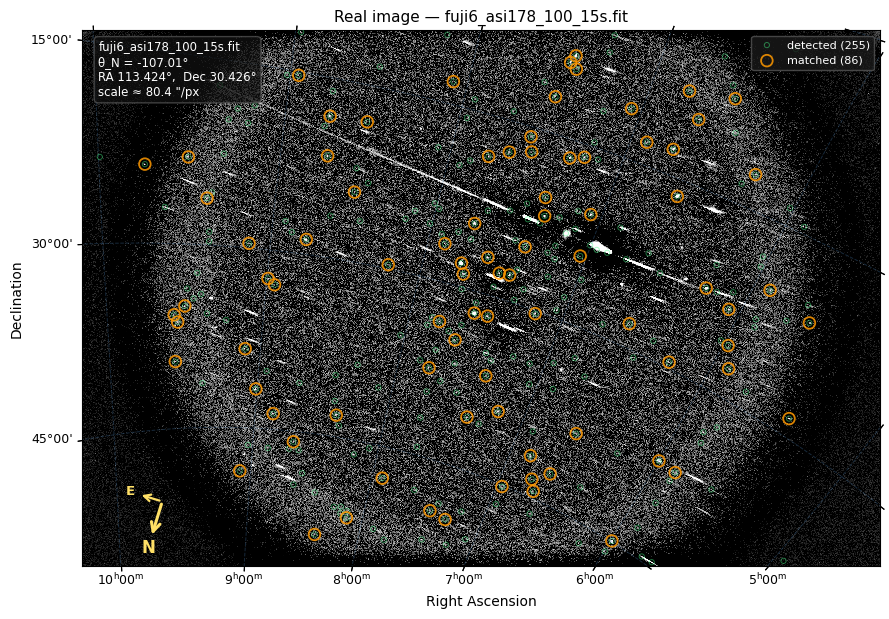

Saved: /mnt/c/Users/bassd/Research/Spectra Angle/spectrangle/out/proposal_fig_v2/proposal_1panel_real.png


In [9]:
fig1 = plt.figure(figsize=(FIG_W_1PAN, FIG_H_1PAN))
fig1.patch.set_facecolor('white')

ax1 = (fig1.add_subplot(1, 1, 1, projection=wcs_real)
       if wcs_real is not None
       else fig1.add_subplot(1, 1, 1))

make_panel(ax1,
           disp_real, vmin_real, vmax_real, nx_real, ny_real,
           result_real, wcs_real, metrics_real,
           title='Real image — ' + REAL_FILE.name,
           file_label=REAL_FILE.name,
           maskang=None, show_gt=False)

fig1.tight_layout()
_out1 = OUT_DIR / 'proposal_1panel_real.png'
fig1.savefig(_out1, dpi=FIG_DPI, bbox_inches='tight')
plt.show()
print(f'Saved: {_out1.resolve()}')


## Quick-reference: adjusting the look

| Goal | Change in Parameters cell |
|:-----|:--------------------------|
| Lighter image | `STRETCH='linear'` or raise `VHI_PCT_*` |
| More contrast | `STRETCH='arcsinh'` + lower `ARCSINH_SCALE_FRAC` |
| More sky background | Lower `VLO_PCT_*` (e.g. 0.1) |
| Brighter stars | Raise `VHI_PCT_*` (e.g. 99.95) |
| Bigger north arrow | Raise `ARROW_LEN_FRAC` (e.g. 0.10) |
| Skip GT placeholder | `show_gt=False` in `make_panel(...)` call |
| Force 110lmm fallback | `FORCE_110_FALLBACK = True` |
| No LR flip on 110lmm | `FLIP_SIM_LR = False` |
